## WACC — costo de capital promedio ponderado

El **WACC** combina el costo del capital propio ($k_e$) y el de la deuda después de
impuestos, ponderados por su peso a valor de mercado:

$$ \text{WACC} = \frac{E}{V}\,k_e + \frac{D}{V}\,k_d\,(1 - T) $$

donde $E$ = valor de mercado del capital propio (capitalización bursátil), $D$ =
deuda con intereses, y $V = E + D$.

**Costo del capital propio por CAPM.** Aquí estimamos $k_e$ con el CAPM, usando el
beta del Módulo 1 y una **prima de riesgo de mercado** calculada como en el taller
de CAPM:

$$ k_e = R_f + \beta\,(R_m - R_f) $$

- $R_f$ = tasa libre de riesgo actual (rendimiento del bono del Tesoro a 10 años, `^TNX`).
- $R_m$ = retorno anualizado del **S&P 500** en un periodo dado.
- $R_m - R_f$ = prima de riesgo del mercado.

**Insumos de módulos previos:** $\beta = 1.09$ (Módulo 1); $k_d = 3.00\%$ y
$T = 17.46\%$ (Módulo 3); $D = 84{,}711$ M (10-Q).

**Tres escenarios.** El resultado depende mucho del periodo con que se estima el
retorno de mercado $R_m$ (y por tanto $k_e$). Calculamos el WACC bajo tres
ventanas históricas del S&P 500 para ver ese rango.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt

from src.yahoo_client import fetch_prices

TICKER = 'AAPL'

# --- Insumos de modulos previos ---
beta  = 1.09          # Modulo 1: beta de Apple
kd    = 0.0300        # Modulo 3: costo de la deuda antes de impuestos
T     = 0.1746        # Modulo 3: tasa impositiva efectiva
kd_di = kd * (1 - T)  # costo de la deuda despues de impuestos

# --- Deuda con intereses (10-Q, 28-mar-2026, US$ millones) ---
D = 84711

# --- Capital propio = capitalizacion de mercado ---
acciones_M = 14667.688                         # acciones en circulacion (10-Q, en millones)
precios = fetch_prices(TICKER, start='2026-01-01', end='2026-07-25')
P0 = float(precios.iloc[-1])
E = P0 * acciones_M                            # market cap, US$ millones

V = E + D
wE, wD = E / V, D / V

# --- Tasa libre de riesgo actual: bono del Tesoro 10 años (^TNX) ---
tnx = fetch_prices('^TNX', start='2026-01-01', end='2026-07-25')
Rf = float(tnx.iloc[-1]) / 100

print(f"Precio AAPL P0:        ${P0:,.2f}")
print(f"Capital propio  E:     ${E:,.0f} M   (peso {wE:.2%})")
print(f"Deuda           D:     ${D:,.0f} M   (peso {wD:.2%})")
print(f"Rf (bono 10 años):    {Rf:.2%}")
print(f"beta:                  {beta}")
print(f"kd despues de imptos:  {kd_di:.2%}")

Precio AAPL P0:        $333.02
Capital propio  E:     $4,884,633 M   (peso 98.30%)
Deuda           D:     $84,711 M   (peso 1.70%)
Rf (bono 10 años):    4.68%
beta:                  1.09
kd despues de imptos:  2.48%


In [2]:
# Tres escenarios: la prima de mercado (y ke) según el periodo del retorno del S&P 500
escenarios = [
    ('Reciente',        '2020-01-01', '2020-2025 (~6a)'),
    ('Con crisis 2008', '2006-01-01', '2006-2025 (~20a)'),
    ('Largo plazo',     '2000-01-01', '2000-2025 (~26a)'),
]

filas = []
for nombre, inicio, etiqueta in escenarios:
    sp = fetch_prices('^GSPC', start=inicio, end='2025-12-31')
    años = (sp.index[-1] - sp.index[0]).days / 365.25
    Rm = (float(sp.iloc[-1]) / float(sp.iloc[0])) ** (1 / años) - 1
    prima = Rm - Rf
    ke = Rf + beta * prima
    wacc = wE * ke + wD * kd_di
    filas.append({'Escenario': nombre, 'Periodo': etiqueta,
                  'Rm': Rm, 'prima': prima, 'ke': ke, 'WACC': wacc})

wacc_df = pd.DataFrame(filas)

# Version formateada para mostrar
tabla = wacc_df.copy()
for c in ['Rm', 'prima', 'ke', 'WACC']:
    tabla[c] = (tabla[c] * 100).round(2).astype(str) + ' %'
tabla = tabla.rename(columns={'prima': 'Prima (Rm-Rf)', 'ke': 'ke (CAPM)'})
tabla

,Escenario,Periodo,Rm,Prima (Rm-Rf),ke (CAPM),WACC
0,Reciente,2020-2025 (~6a),13.33 %,8.65 %,14.11 %,13.91 %
1,Con crisis 2008,2006-2025 (~20a),8.84 %,4.16 %,9.21 %,9.1 %
2,Largo plazo,2000-2025 (~26a),6.17 %,1.49 %,6.3 %,6.24 %


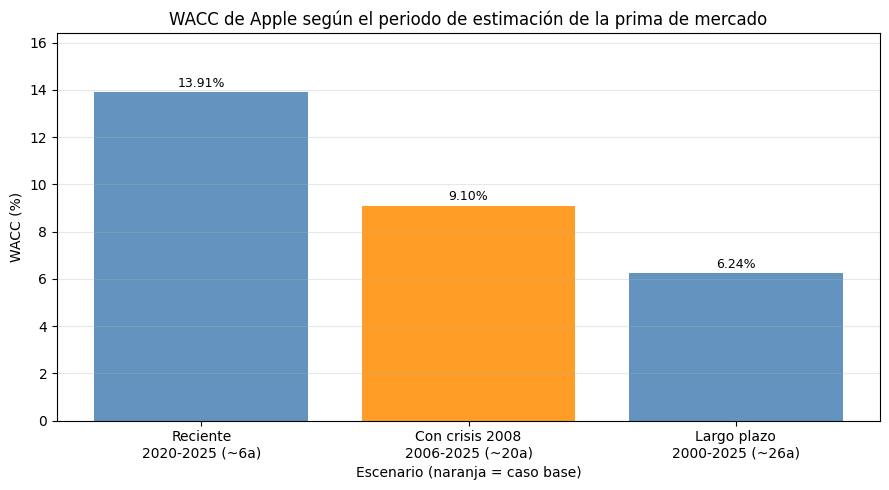

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

etiquetas = [f'{r.Escenario}\n{r.Periodo}' for r in wacc_df.itertuples()]
vals = (wacc_df['WACC'] * 100).values
colores = ['darkorange' if r.Escenario == 'Con crisis 2008' else 'steelblue'
           for r in wacc_df.itertuples()]

ax.bar(etiquetas, vals, color=colores, alpha=0.85)
for xi, yi in zip(etiquetas, vals):
    ax.text(xi, yi + 0.1, f'{yi:.2f}%', ha='center', va='bottom', fontsize=9)

ax.set_title('WACC de Apple según el periodo de estimación de la prima de mercado',
             fontsize=12)
ax.set_xlabel('Escenario (naranja = caso base)')
ax.set_ylabel('WACC (%)')
ax.margins(y=0.18)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación · WACC de Apple

**Resultado final (caso base): WACC ≈ 9.1 %.** Tomamos como base el escenario de
20 años (2006–2025), que incluye la crisis de 2008 y arroja una prima de mercado
de ~4.2 % —el nivel más realista de los tres—.

**Apple se financia casi enteramente con capital propio.** A valor de mercado, el
patrimonio pesa 98.3 % (capitalización de ~US$4.9 billones) y la deuda solo 1.7 %.
Por eso el WACC ≈ kₑ: aunque la deuda es baratísima (2.48 % después de impuestos),
su peso mínimo apenas mueve el resultado (aporta ~0.04 puntos al WACC).

**El WACC es muy sensible al periodo con que se estima la prima de mercado:**

| Escenario | Periodo Rm | Rm | Prima | kₑ (CAPM) | WACC |
|---|---|---:|---:|---:|---:|
| Reciente | 2020–2025 (~6a) | 13.33 % | 8.65 % | 14.11 % | 13.91 % |
| **Con crisis 2008 (base)** | 2006–2025 (~20a) | 8.84 % | 4.16 % | 9.21 % | **9.10 %** |
| Largo plazo | 2000–2025 (~26a) | 6.17 % | 1.49 % | 6.30 % | 6.24 % |

El rango va de **6.2 % a 13.9 %**: casi 8 puntos, solo por cambiar la ventana del
retorno de mercado. Las ventanas cortas (2020–2025) ven únicamente el mercado
alcista post-COVID y elevan la prima; las largas incorporan las caídas (dot-com,
2008) y la reducen.

**Dos advertencias sobre la prima:**

- Usamos el retorno de *precio* del S&P 500 (sin dividendos, ~2 %/año), así que las
  primas quedan algo subestimadas —sobre todo la de largo plazo (1.49 %), demasiado
  baja para ser realista—.
- La prima histórica típica del mercado ronda 4.5 %–5.5 %, cercana al escenario base
  (2006–2025).

> **En el conjunto del proyecto:** el kₑ por CAPM del caso base (9.2 %) es más alto
> que el de Gordon (4.5 %–7.9 %, Módulo 2), lo que confirma que el modelo de Gordon
> subestima el costo del capital propio de Apple por su bajo dividendo. Un **WACC
> cercano a 9 %** es coherente con las estimaciones habituales para Apple (~8 %–10 %).